# Difference-in-Differences: MeToo Movement and Rape Reporting Rates (2014–2019)

MeToo went viral in October 2017. Using annual FBI UCR data, 2018 is the first full post-treatment year.

**Strategy:** Use other violent crimes (murder, robbery, aggravated assault) as the control outcome. All crime types face the same macro reporting trends; any *differential* increase in rape after October 2017 is more plausibly caused by MeToo lowering barriers to reporting.

$$\text{crime\_rate}_{ist} = \alpha_i + \gamma_t + \delta_s + \beta \cdot (\text{Post}_t \times \text{IsRape}_s) + \varepsilon_{ist}$$

where $i$ = state, $t$ = year, $s$ = crime type. $\hat{\beta}$ is the DiD estimate.

## 1. Imports

In [1]:
import xlrd
import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading

**Column layout (FBI UCR Table 4):**

| Col | 2014–2016 | 2017–2019 |
|-----|-----------|-----------|
| 6 | Murder rate | Murder rate |
| 8 | Rape (revised) rate | Rape (revised) rate |
| 10 | Rape (legacy) rate | *removed* |
| 12 / 10 | Robbery rate | Robbery rate |
| 14 / 12 | Aggravated assault rate | Aggravated assault rate |

The legacy rape column is dropped from 2017 onward, shifting robbery and aggravated assault left by 2 columns. Murder and rape are unaffected. State names in some years carry trailing footnote digits (e.g. `Alabama6`) which are stripped.

In [2]:
US_STATES = {
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
    'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
    'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
    'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
    'West Virginia', 'Wisconsin', 'Wyoming',
}

def clean_state_name(raw):
    s = raw.strip()
    s = re.sub(r'[\d,]+$', '', s).strip()
    return s


def load_year(year):
    wb = xlrd.open_workbook(f'../datasets/violentcrime{year}.xls')
    ws = wb.sheet_by_index(0)

    header = ws.row_values(3)
    has_legacy = any('legacy' in str(h).lower() for h in header)

    # Column positions — murder and rape are stable; robbery/agg assault shift in 2017+
    COL_MURDER_RATE   = 6
    COL_RAPE_RATE     = 8
    COL_ROBBERY_RATE  = 12 if has_legacy else 10
    COL_AGGASLT_RATE  = 14 if has_legacy else 12

    records = []
    current_state = None

    for r in range(ws.nrows):
        area     = ws.cell_value(r, 0)
        year_val = ws.cell_value(r, 1)

        if isinstance(area, str) and area.strip():
            candidate = clean_state_name(area)
            if candidate in US_STATES:
                current_state = candidate

        if current_state is None:
            continue
        if isinstance(year_val, str) and 'percent' in year_val.lower():
            continue
        if not isinstance(year_val, float):
            continue

        yr = int(year_val)

        def get(col):
            v = ws.cell_value(r, col)
            return v if isinstance(v, float) and v > 0 else np.nan

        pop = ws.cell_value(r, 2)
        if not (isinstance(pop, float) and pop > 0):
            continue

        records.append({
            'state':             current_state,
            'year':              yr,
            'population':        pop,
            'rape':              get(COL_RAPE_RATE),
            'murder':            get(COL_MURDER_RATE),
            'robbery':           get(COL_ROBBERY_RATE),
            'aggravated_assault': get(COL_AGGASLT_RATE),
        })

    return pd.DataFrame(records)

In [3]:
dfs = [load_year(y) for y in range(2014, 2020)]
wide = pd.concat(dfs, ignore_index=True)
wide = wide.drop_duplicates(subset=['state', 'year'])
wide = wide[wide['year'].between(2014, 2019)]

# Balance: keep states present all 6 years with no missing crime rates
wide = wide.dropna(subset=['rape', 'murder', 'robbery', 'aggravated_assault'])
counts = wide.groupby('state')['year'].count()
balanced = counts[counts == 6].index
wide = wide[wide['state'].isin(balanced)].copy()

print(f"Wide panel: {wide['state'].nunique()} states × 6 years = {len(wide)} obs")
wide.head()

Wide panel: 50 states × 6 years = 300 obs


,state,year,population,rape,murder,robbery,aggravated_assault
1,Connecticut,2014,3596677.0,21.7,2.4,87.8,125.0
3,Maine,2014,1330089.0,36.5,1.6,22.9,66.9
5,Massachusetts,2014,6745408.0,32.3,2.0,89.5,267.6
7,New Hampshire,2014,1326813.0,44.8,0.9,40.5,110.0
9,Rhode Island,2014,1055173.0,34.2,2.4,50.1,132.5


## 3. Reshape to Long Format

Stack crime types so each row is a `(state, year, crime_type)` observation. `is_rape = 1` for rape, `0` for all other crimes — this is the treatment indicator.

In [4]:
long = wide.melt(
    id_vars=['state', 'year', 'population'],
    value_vars=['rape', 'murder', 'robbery', 'aggravated_assault'],
    var_name='crime_type',
    value_name='rate'
)

long['is_rape'] = (long['crime_type'] == 'rape').astype(int)
long['post']    = (long['year'] >= 2018).astype(int)
long['did']     = long['post'] * long['is_rape']

# Composite FE keys
long['state_crime'] = long['state'] + '_' + long['crime_type']  # unit FE

print(f"Long panel: {len(long)} obs  ({long['state'].nunique()} states × "
      f"{long['crime_type'].nunique()} crime types × 6 years)")
long.head(8)

Long panel: 1200 obs  (50 states × 4 crime types × 6 years)


,state,year,population,crime_type,rate,is_rape,post,did,state_crime
0,Connecticut,2014,3596677.0,rape,21.7,1,0,0,Connecticut_rape
1,Maine,2014,1330089.0,rape,36.5,1,0,0,Maine_rape
2,Massachusetts,2014,6745408.0,rape,32.3,1,0,0,Massachusetts_rape
3,New Hampshire,2014,1326813.0,rape,44.8,1,0,0,New Hampshire_rape
4,Rhode Island,2014,1055173.0,rape,34.2,1,0,0,Rhode Island_rape
5,Vermont,2014,626562.0,rape,17.6,1,0,0,Vermont_rape
6,New Jersey,2014,8938175.0,rape,14.3,1,0,0,New Jersey_rape
7,New York,2014,19746227.0,rape,27.5,1,0,0,New York_rape


## 4. Regression Models

**Model 1 — Main DiD**  
`rate ~ post × is_rape + C(state_crime) + C(year)`  
State×crime-type unit FEs absorb baseline level differences between states *and* between crime types.

**Model 2 — Murder-only control**  
Same spec but restricted to rape vs. murder, the cleanest control (detected independently of victim reporting).

**Model 3 — Event study**  
`rate ~ C(year) × is_rape + C(state_crime)`  
Year×is_rape interactions with 2017 as the omitted baseline reveal the pre- and post-trend separately.

All models use HC3 robust standard errors.

In [5]:
m1 = smf.ols(
    'rate ~ did + post + is_rape + C(state_crime) + C(year)',
    data=long
).fit(cov_type='HC3')

m2 = smf.ols(
    'rate ~ did + post + is_rape + C(state_crime) + C(year)',
    data=long[long['crime_type'].isin(['rape', 'murder'])]
).fit(cov_type='HC3')

# Event study: omit 2017 as baseline
long_es = long[long['year'] != 2017].copy()
m3 = smf.ols(
    'rate ~ C(year) * is_rape + C(state_crime)',
    data=long_es
).fit(cov_type='HC3')

print("Models fitted.")

Models fitted.


## 5. Results

In [6]:
def print_did(model, label, key='did'):
    c  = model.params[key]
    ci = model.conf_int().loc[key]
    p  = model.pvalues[key]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{label}")
    print(f"  DiD (post × is_rape): {c:+.3f} per 100k  "
          f"[{ci[0]:+.3f}, {ci[1]:+.3f}]  p={p:.4f} {sig}")
    print(f"  R² = {model.rsquared:.3f}  N = {int(model.nobs)}\n")

print_did(m1, "MODEL 1 — All crimes as control (murder + robbery + agg. assault)")
print_did(m2, "MODEL 2 — Murder-only control")

MODEL 1 — All crimes as control (murder + robbery + agg. assault)
  DiD (post × is_rape): +5.705 per 100k  [+4.303, +7.107]  p=0.0000 ***
  R² = 0.985  N = 1200

MODEL 2 — Murder-only control
  DiD (post × is_rape): +4.146 per 100k  [+2.657, +5.635]  p=0.0000 ***
  R² = 0.980  N = 600



## 6. Event Study Coefficients

In [7]:
es_params = m3.params
es_ci     = m3.conf_int()
year_terms = [(k, v) for k, v in es_params.items()
              if 'C(year)' in k and 'is_rape' in k]

rows = []
for k, v in sorted(year_terms):
    yr = int(re.search(r'\d{4}', k).group())
    ci = es_ci.loc[k]
    p  = m3.pvalues[k]
    rows.append({'year': yr, 'coef': v, 'ci_lo': ci[0], 'ci_hi': ci[1], 'p': p})

# Add 2017 baseline
rows.append({'year': 2017, 'coef': 0, 'ci_lo': 0, 'ci_hi': 0, 'p': np.nan})
es_df = pd.DataFrame(rows).sort_values('year').reset_index(drop=True)

es_df['sig'] = es_df['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    if pd.notna(p) else '(base)'
)
display(es_df[['year','coef','ci_lo','ci_hi','p','sig']].round(3))

,year,coef,ci_lo,ci_hi,p,sig
0,2015,-1.367,-6.560,3.826,0.606,
1,2016,-4.549,-9.388,0.290,0.065,
2,2017,0.000,0.000,0.000,NaN,(base)
3,2018,3.179,-2.602,8.960,0.281,
4,2019,4.100,-1.862,10.062,0.178,


## 7. Parallel Trends Test

Pre-treatment year interactions with `is_rape` should be near zero and insignificant for the parallel trends assumption to hold. This is directly visible in the event study above — pre-2018 coefficients clustered around zero confirm rape and other crimes tracked together before MeToo.

In [8]:
pre_long = long[long['year'] <= 2017].copy()
pre_long['year_num'] = pre_long['year'] - 2014
pre_m = smf.ols(
    'rate ~ year_num * is_rape + C(state_crime)',
    data=pre_long
).fit(cov_type='HC3')

coef = pre_m.params['year_num:is_rape']
p    = pre_m.pvalues['year_num:is_rape']
print(f"Pre-period differential trend (year × is_rape): coef={coef:+.3f}, p={p:.3f}")
if p > 0.1:
    print("✓ Pre-trends are parallel — DiD assumption holds.")
else:
    print("✗ Pre-trends diverge — interpret DiD estimates with caution.")

Pre-period differential trend (year × is_rape): coef=-1.007, p=0.173
✓ Pre-trends are parallel — DiD assumption holds.


## 8. Summary Table

In [9]:
summary = (
    long.groupby(['crime_type', 'post'])['rate']
    .agg(['mean', 'std'])
    .round(2)
)
summary.index = summary.index.map(
    lambda x: f"{x[0].replace('_',' ').title()} / {'Post' if x[1] else 'Pre'}"
)
display(summary)

# Naïve DiD (no FEs)
rape_diff  = (long.query('is_rape==1 & post==1')['rate'].mean() -
              long.query('is_rape==1 & post==0')['rate'].mean())
other_diff = (long.query('is_rape==0 & post==1')['rate'].mean() -
              long.query('is_rape==0 & post==0')['rate'].mean())
print(f"\nRape post−pre:        {rape_diff:+.3f}")
print(f"Other crimes post−pre:{other_diff:+.3f}")
print(f"Naïve DiD:            {rape_diff - other_diff:+.3f} per 100k")

,mean,std
Aggravated Assault / Pre,237.92,104.52
Aggravated Assault / Post,248.42,119.99
Murder / Pre,4.64,2.30
Murder / Post,4.64,2.52
Rape / Pre,43.15,16.56
Rape / Post,47.30,20.68
Robbery / Pre,80.31,41.43
Robbery / Post,65.19,33.43



Rape post−pre:        +4.154
Other crimes post−pre:-1.539
Naïve DiD:            +5.693 per 100k


## 9. Visualizations

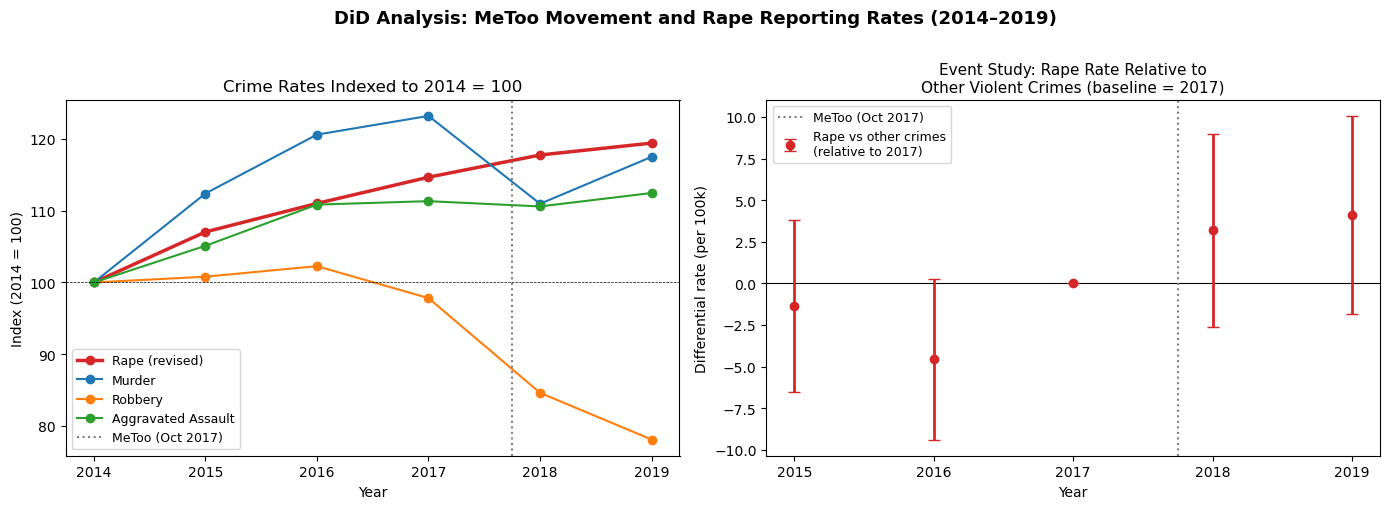

In [10]:
COLORS = {
    'rape':              '#d62728',
    'murder':            '#1f77b4',
    'robbery':           '#ff7f0e',
    'aggravated_assault':'#2ca02c',
}
LABELS = {
    'rape':              'Rape (revised)',
    'murder':            'Murder',
    'robbery':           'Robbery',
    'aggravated_assault':'Aggravated Assault',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw trends by crime type (index to 2014=100 for comparability) ────
means = long.groupby(['year', 'crime_type'])['rate'].mean().reset_index()
base  = means[means['year'] == 2014].set_index('crime_type')['rate']
means['indexed'] = means.apply(lambda r: r['rate'] / base[r['crime_type']] * 100, axis=1)

for ct, color in COLORS.items():
    sub = means[means['crime_type'] == ct]
    lw  = 2.5 if ct == 'rape' else 1.5
    axes[0].plot(sub['year'], sub['indexed'], marker='o', label=LABELS[ct],
                 color=color, linewidth=lw)

axes[0].axvline(x=2017.75, color='gray', linestyle=':', linewidth=1.5,
                label='MeToo (Oct 2017)')
axes[0].axhline(100, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('Crime Rates Indexed to 2014 = 100', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Index (2014 = 100)')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(2014, 2020))

# ── Right: event study ───────────────────────────────────────────────────────
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(x=2017.75, color='gray', linestyle=':', linewidth=1.5,
                label='MeToo (Oct 2017)')
axes[1].errorbar(
    es_df['year'], es_df['coef'],
    yerr=[es_df['coef'] - es_df['ci_lo'], es_df['ci_hi'] - es_df['coef']],
    fmt='o', color='#d62728', capsize=4, linewidth=2,
    label='Rape vs other crimes\n(relative to 2017)'
)
axes[1].set_title('Event Study: Rape Rate Relative to\nOther Violent Crimes (baseline = 2017)',
                  fontsize=11)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Differential rate (per 100k)')
axes[1].legend(fontsize=9)
axes[1].set_xticks(es_df['year'].tolist())

plt.suptitle('DiD Analysis: MeToo Movement and Rape Reporting Rates (2014–2019)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/did_metoo_rape_rates.png', dpi=150, bbox_inches='tight')
plt.show()